In [1]:
import eagleSqlTools as sql
import numpy as np
import matplotlib.pyplot as plt
import time
import os

In [2]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [3]:
snapnum_list = [17]
h = 0.6777

In [4]:
mySims = np.array([("RefL0100N1504", 100.) , ("AGNdT9L0050N0752", 50.) , ("RecalL0025N0752", 25.)])
# This us es t h e e a g l e S q l T o o l s module t o connec t t o t h e d a t a b a s e w i th your username and password .
# I f t h e password i s not g i v en , t h e module w i l l prompt f o r i t .
con = sql.connect("knz702", password="IG60KPB1")
for snapnum in snapnum_list:
    start = time.time()
    for sim_name , sim_size in mySims[:1]:
        print(sim_name)
    # Cons t ru c t and e x e c u t e que ry f o r each s im u l a t i o n . This que ry r e t u r n s t h e number o f g a l a x i e s
    # f o r a g i v en 30 pkpc a p e r t u r e s t e l l a r mass b in ( c en t e r e d w i th 0 .2 dex w id th ) .
        myQuery = f"SELECT \
                        SH.StarFormationRate as sfr, \
                        SH.SubGroupNumber as snumber, \
                        SH.Redshift as z, \
                        SH.GroupID as groupID, \
                        FOF.Group_M_TopHat200*{h} as mvir, \
                        SH.CentreOfPotential_x*{h} as x_pos, \
                        SH.CentreOfPotential_y*{h} as y_pos, \
                        SH.CentreOfPotential_z*{h} as z_pos, \
                        SH.Vmax as vmax, \
                        SH.VmaxRadius as rmax \
                    FROM \
                        %s_SubHalo as SH, \
                        %s_FOF as FOF \
                    WHERE \
                        SH.SnapNum = {snapnum} \
                        and FOF.SnapNum = SH.SnapNum \
                        and FOF.GroupID = SH.GroupID \
                    ORDER BY \
                    mass"%(sim_name, sim_name)
        # Execu te que ry .
        data = sql.execute_query (con , myQuery)

RefL0100N1504


In [5]:
sort_indices = np.argsort(data["groupID"])
groupids = data["groupID"][sort_indices]
sfr_sub = data["sfr"][sort_indices]
cent_vmax = data["vmax"][sort_indices]
cent_rmax = data["rmax"][sort_indices]
mvir1 = data["mvir"][sort_indices]
pos_x1 = data["x_pos"][sort_indices]
pos_y1 = data["y_pos"][sort_indices]
pos_z1 = data["z_pos"][sort_indices]
subgroup_number = data["snumber"][sort_indices]

In [6]:
unique_ids, indices = np.unique(groupids, return_index=True)

In [ ]:
group_sfrs = np.add.reduceat(sfr_sub, indices)
group_sfrs = np.log10(group_sfrs)

/tmp/ipykernel_250919/1663907034.py:2: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(group_sfrs)


In [ ]:
mvir = np.log10(mvir1[indices])
pos_x = pos_x1[indices]
pos_y = pos_y1[indices]
pos_z = pos_z1[indices]

/tmp/ipykernel_250919/2867838504.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(mvir1[indices])


In [9]:
mask = subgroup_number == 0
cent_cprox = cent_vmax[mask]/cent_rmax[mask]

[ 1.52654552  3.88606071  5.6528759   7.55174232 22.76908112]


Text(0.3, 0.85, '$\\widetilde{V}_{\\rm max}$ % bins')

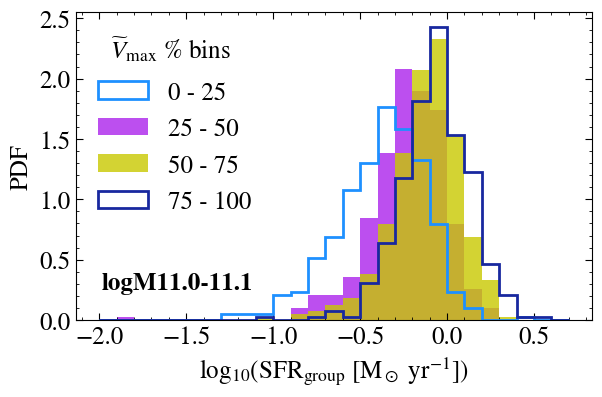

In [10]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
#color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
color_list = ["#23AAEB","#AC23EB","#c8c800","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["green","#AC23EB","#c8c800","#18289F"]
color_list = ["dodgerblue", "#AC23EB", "#c8c800","#18289F"]
logM = 11.0
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(cent_cprox[mask2])
mask_high = cent_cprox[mask2] > median
mask_low = cent_cprox[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
#percentile_list = [0,50,100]
percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1])
    masks.append(mask)
    if (i == 1) or (i == 2):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.8, color=color_list[i])# facecolor="none", edgecolor=color_list[i])
    elif (i == 0) or (i == 3):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step', linewidth=2)# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.05,0.1), xycoords="axes fraction", ha="left", weight="bold")

#plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"$\widetilde{V}_{\rm max}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")

#plt.savefig("../../figures/hist_logM11-11.1_conc_proxy_eagle.pdf", format="pdf", bbox_inches="tight")

In [11]:

logMs = np.arange(11,13.2, 0.1)
nbins = len(logMs)


new_medians_arr = np.zeros((4,nbins), dtype=float)
new_iqrs_arr = np.zeros((4,nbins), dtype=float)

orig_iqrs = []
orig_medians = []
nhalos = []

for ibin, logM in enumerate(logMs):
    mask2 = (mvir> logM) & (mvir < logM+0.1)
    nhalos.append(np.sum(mask2))
    if np.sum(mask2) > 4:
        percentile_list = [0, 25, 50, 75, 100]
        percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)
    

        
        ps = np.nanpercentile(group_sfrs[mask2], q=[25,75])
        iqr = ps[1] - ps[0]
        orig_iqrs.append(iqr)
        
        med = np.nanpercentile(group_sfrs[mask2], q=[50])
        orig_medians.append(med)
        
        iqrs = []
        sigmas = []
        new_medians = []
        for ip, percentile in enumerate(percentiles[:4]):
            mask = (cent_cprox[mask2] > percentiles[ip]) & (cent_cprox[mask2] < percentiles[ip+1]) #& (group_sfrs[mask2] > -5)
            masks.append(mask)
            #plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
            
            #print(logM)
            #print(ps)
            
            ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
            iqr = ps[1] - ps[0]
            iqrs.append(iqr)
            #print(np.nanstd(group_sfrs[mask2][mask]))
            med = np.nanmedian(group_sfrs[mask2][mask])
            new_medians.append(med)
            new_medians_arr[ip][ibin] = med
            new_iqrs_arr[ip][ibin] = iqr

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250919/2262628304.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


(10.9, 14.1)

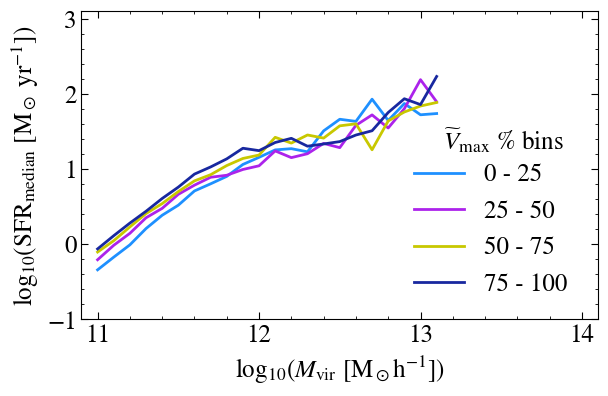

In [12]:
for ip in range(4):
    plt.plot(logMs, new_medians_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip],linewidth=2)
    

#plt.plot(logMs, orig_medians, color=palette_tab10[3] , linestyle="dashed")
    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$\widetilde{V}_{\rm max}$ % bins", (0.7,0.55), xycoords="axes fraction", ha="left")

#plt.annotate("Median of each"+ "\n" + r"$\widetilde{V}_{\rm max}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)
plt.xlim(10.9,14.1)
#plt.savefig("../../figures/median_conc_proxy_eagle.pdf", format="pdf", bbox_inches="tight")

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250919/1645703915.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


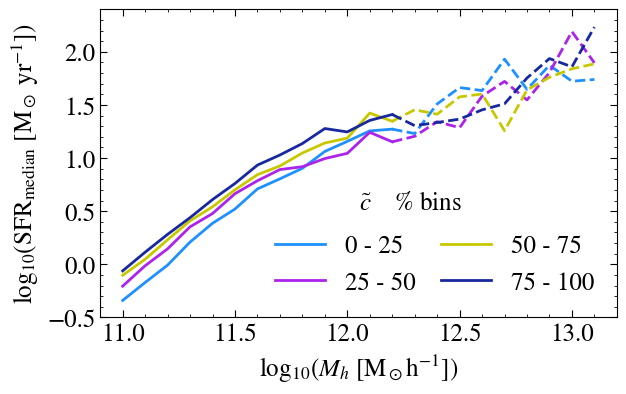

In [13]:
index = nhalos.index(117)
for ip in range(4):
    plt.plot(logMs[:index+1], new_medians_arr[ip][:index+1],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    plt.plot(logMs[index:], new_medians_arr[ip][index:], color=color_list[ip], linestyle="dashed")

    
plt.legend(loc="lower right", bbox_to_anchor=(1,0), ncol=2, columnspacing=1)
plt.annotate(r"$\tilde{c}\quad$ % bins", (0.5,0.35), xycoords="axes fraction", ha="left")
#plt.annotate("Median of each"+ "\n" + r"$M_{\rm sat}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_h$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-0.5,2.4)
plt.xlim(10.9,13.2)

plt.savefig("../../figures/median_conc_proxy_eagle_w_dashed.pdf", format="pdf", bbox_inches="tight")